The probability density function of two 1D Gaussians with variances $\sigma_1^2$, $\sigma_2^2$, means $\mu_1$, $\mu_2$, and mixture fraction $\pi$:
\begin{equation}
    P(x) = \pi \cdot \mathcal{N}(x|\mu_1, \sigma_1^2) + (1-\pi) \cdot \mathcal{N}(x|\mu_2, \sigma_2^2)
\end{equation}

As a second piece, we need the negative log-likelihood:
\begin{equation}
    \text{NLL} = -\sum{}{}{\log{P(x)}}
\end{equation}

Using pretty much any optimizer, we can then fit a GMM by minimizing the NLL:
\begin{equation}
    \argmin_{\sigma_1^2, \sigma_2^2, \pi}{(\text{NLL})}
\end{equation}

3 [1.60061416e+02 3.20346744e+02 5.21522595e+02 1.34888871e+01
 1.99281701e+01 5.20608059e+01 6.00000415e-01 2.99958347e-01
 1.00041237e-01]


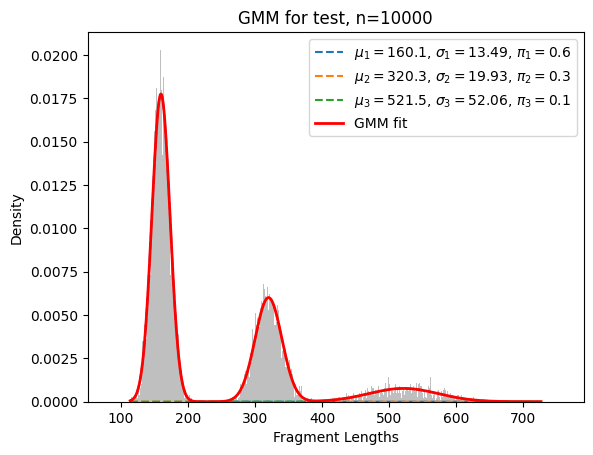

In [7]:
from pyfraglib.math import fit_gmm, plot_gmm
import numpy as np
import numpy.typing as npt

n: int = 10000

mean1, mean2, mean3 = 160.0, 320.0, 520.0
std1, std2, std3 = 13.5, 20.0, 55.0
pi1, pi2, pi3 = 0.6, 0.3, 0.1

data1: npt.NDArray[np.float64] = np.random.normal(loc=mean1, scale=std1, size=int(n * pi1))
data2: npt.NDArray[np.float64] = np.random.normal(loc=mean2, scale=std2, size=int(n * pi2))
data3: npt.NDArray[np.float64] = np.random.normal(loc=mean3, scale=std3, size=int(n * pi3))
data: npt.NDArray[np.float64] = np.hstack([data1, data2, data3])  # type: ignore

n, params = fit_gmm(data, "../config/gmm.json")
print(n, params)
plot_gmm(data, n, params, ".", "test")